# 🧠 Smart Healthcare Assistant for Breast Disease Prediction  
### 💉 Leveraging Machine Learning and Explainable AI for Early Detection

---

## 📘 Introduction

Imagine a world where a simple algorithm could help detect breast cancer early — saving time, resources, and lives. In this project, we explore how Artificial Intelligence can be transformed into a **virtual healthcare assistant** that supports doctors in diagnosing breast cancer more efficiently and transparently.

Breast cancer is among the **most diagnosed cancers globally**, and early detection is key to improving patient outcomes. However, diagnosis can be delayed due to limited access to specialists, human error, or lack of advanced diagnostic tools.

That’s where our **Smart Healthcare Assistant** steps in. 🩺

Using the **Wisconsin Breast Cancer Dataset**, we train a machine learning model that classifies tumors as either:
- ✅ **Benign** (non-cancerous)
- ❌ **Malignant** (cancerous)

But we don’t stop at predictions. To ensure **trust and transparency**, we integrate **Explainable AI (XAI)** tools like **SHAP** to explain *why* a prediction was made — making the system not just smart, but understandable.

    ## 🎯 What This Project Aims to Do:

- 🔍 Predict breast cancer risk using medical features (e.g., cell radius, smoothness, concavity)
- 🧠 Build a machine learning model with high accuracy and low false negatives
- 💬 Use **SHAP values** to visualize and explain model decisions
- 🧾 Recommend further steps like diagnostic tests or lifestyle changes
- 💻 Create a foundation for future integration into digital health systems

---

> 🎓 This project blends data science and healthcare — showing how AI can assist, not replace, medical professionals. 


## 📥 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import os

folder_path = r"C:\Users\hp\Desktop\Breast Disease Prediction"
print(os.listdir(folder_path))

['.idea', 'app.py', 'Breast Cancer Prediction.ipynb', 'breast_cancer.csv', 'desktop.ini', 'model.pkl', 'static', 'templates']


## 📂 Load the Dataset

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pickle


data = pd.read_csv(r"C:\Users\hp\Desktop\Breast Disease Prediction\breast_cancer.csv", header=None, skiprows=1)


column_names = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst',
    'diagnosis'
]
data.columns = column_names

print(data.head())


   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave_points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  texture_worst  perimeter_worst  area_worst  \
0             

## **⚙️  Data Preprocessing**

In [3]:
data.shape

(569, 31)

In [4]:
data.isnull().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
diagnosis                  0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(0)

## 🧠**Encoding the Target Variable**

In [6]:
print(data['diagnosis'].unique())

[0 1]


In [7]:
print(data['diagnosis'].value_counts())

diagnosis
1    357
0    212
Name: count, dtype: int64


## 🧪 **Splitting Data into Training and Testing Sets**

In [8]:
x = data.drop('diagnosis',axis=1)
y = data['diagnosis']

In [9]:
x.shape

(569, 30)

In [10]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [11]:
x_train.shape

(455, 30)

In [12]:
x_test.shape

(114, 30)

## **🤖 Feature Scaling**

In [13]:
sc = StandardScaler()

In [14]:
sc.fit(x_train)

StandardScaler()

In [15]:
x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

In [16]:
x_train

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

## ⚙️  **Training Model**

In [17]:
lg = LogisticRegression()

In [18]:
lg.fit(x_train,y_train)
y_pred = lg.predict(x_test)

In [19]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [20]:
accuracy_score(y_test,y_pred)

0.9736842105263158

## **📌Prediction System**

In [21]:
input_text = (-1.21339378, -0.4976419 ,  0.61365274, -0.49813131, -0.53102815,
       -0.57694824, -0.17494424, -0.36215622, -0.284859  ,  0.43345165,
        0.17818232, -0.36844966,  0.55310406, -0.31671104, -0.40524636,
        0.04025752, -0.03795529, -0.18043065,  0.16478901, -0.12170969,
        0.23079329, -0.50044002,  0.81940367, -0.46922838, -0.53308833,
       -0.04910117, -0.04160193, -0.14913653,  0.09681787,  0.10617647)

np_df = np.asarray(input_text)
prediction = lg.predict(np_df.reshape(1,-1))

if prediction[0] == 1:
    print("Cancrous")
else:
    print("non-cancrous")

Cancrous


In [22]:
x_train[10]

array([-0.4976419 ,  0.61365274, -0.49813131, -0.53102815, -0.57694824,
       -0.17494424, -0.36215622, -0.284859  ,  0.43345165,  0.17818232,
       -0.36844966,  0.55310406, -0.31671104, -0.40524636,  0.04025752,
       -0.03795529, -0.18043065,  0.16478901, -0.12170969,  0.23079329,
       -0.50044002,  0.81940367, -0.46922838, -0.53308833, -0.04910117,
       -0.04160193, -0.14913653,  0.09681787,  0.10617647,  0.49035329])

## **📊 Exploratory Data Analysis**

### **Class distribution**

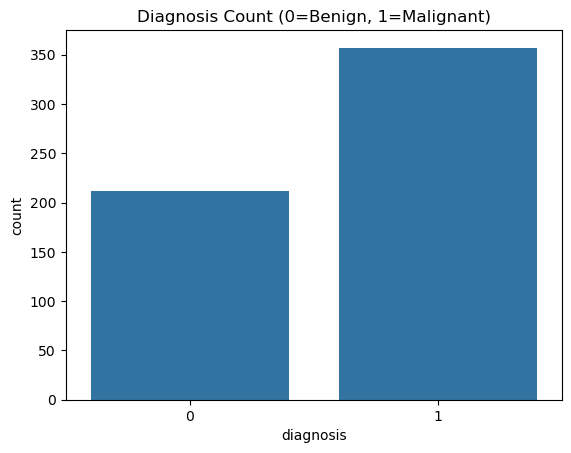

In [23]:
sns.countplot(x='diagnosis', data=data)
plt.title("Diagnosis Count (0=Benign, 1=Malignant)")
plt.show()

### **Correlation Heatmap**

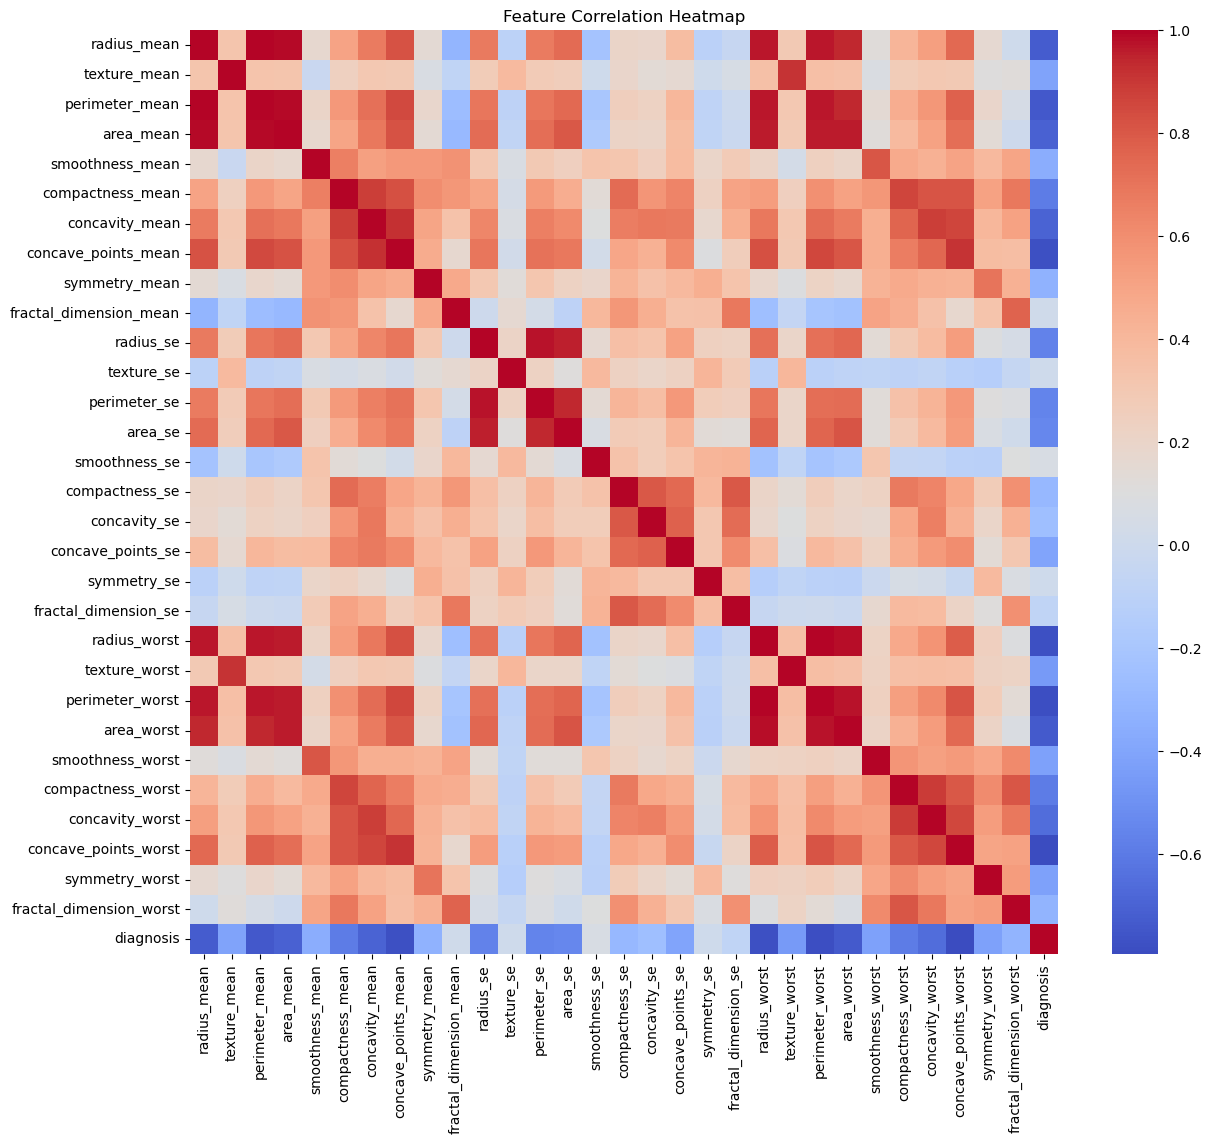

In [24]:
plt.figure(figsize=(14,12))
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## **📉 Confusion Matrix**

### **Plot confusion matrix**

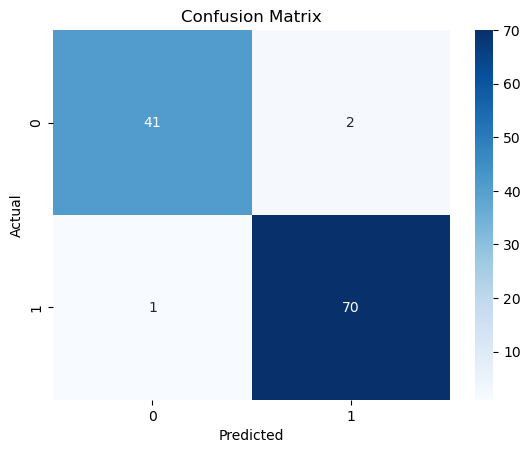

In [25]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## **📈 Feature Importance Visualization**

### **Feature importance from the Random Forest model**

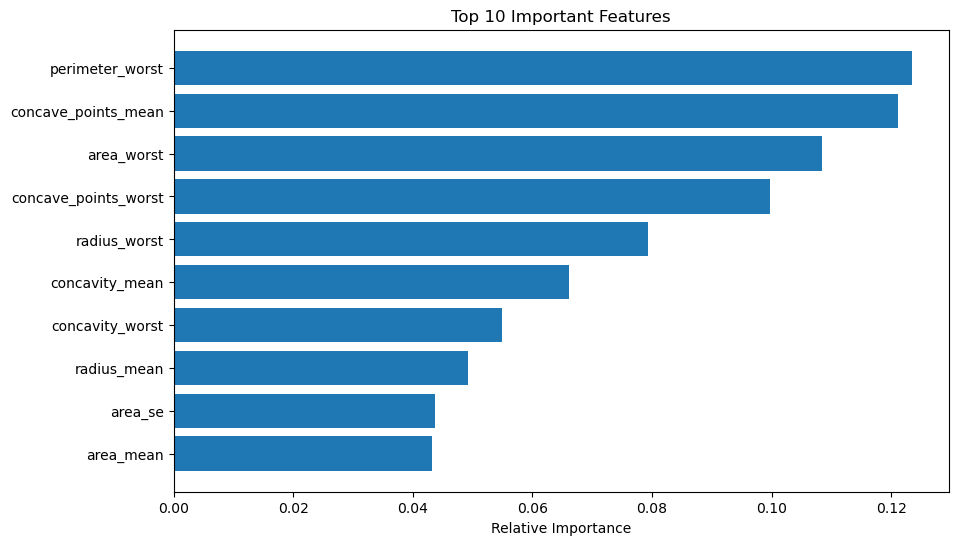

In [26]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
importances = rf.feature_importances_
features = x.columns
indices = np.argsort(importances)[-10:]  # Top 10

plt.figure(figsize=(10, 6))
plt.title("Top 10 Important Features")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


In [27]:
import pickle
pickle.dump(lg,open('model.pkl','wb'))